In [1]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def preparar_dataset_community():
    file_data = "communities.data" # Path to local dataset
    file_names = "communities.names"

    # Read data
    df = pd.read_csv(file_data, header=None, na_values="?")

    # Read column names from the .names file
    with open(file_names) as f:
        lines = f.readlines()
    columns = [line.split()[1] for line in lines if line.startswith("@attribute")]

    # Assign columns to dataframe
    df.columns = columns

    non_predictive_columns = ['state', 'county', 'community', 'communityname', 'fold']
    df.drop(columns=non_predictive_columns, inplace=True)

    # Drop rows with missing values
    na_counts = df.isna().sum()

    # Get columns with more than 1 NaNs and drop them
    cols_to_drop = na_counts[na_counts > 1].index
    df.drop(columns=cols_to_drop, inplace=True)

    # Get columns with at most 1 NaNs and drop rows where they are NaN
    cols_to_check = na_counts[na_counts <= 1].index
    df.dropna(subset=cols_to_check, inplace=True)
    #print(f"DataFrame shape: {df.shape} (rows, columns)")
        
    # Separate features and labels
    X = df.drop(columns=["ViolentCrimesPerPop"])
    y = 1-df["ViolentCrimesPerPop"].values # 1 = lower crime rate, 0 = higher crime rate
    col_names = X.columns
    scaler = MinMaxScaler()
    X = scaler.fit_transform(X)
    return X,y,col_names

In [2]:
X,y,col_names = preparar_dataset_community()


In [35]:
import numpy as np
X.shape

(1993, 100)

<h1>Linear Regression</h1>

In [3]:
from LinearRegressionDRO import LinearRegressionDRO
prueba = LinearRegressionDRO(X,y)
prueba.fit()


<h2>p=1</h2>

In [31]:
import numpy as np
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
lis = list(np.arange(100, 120, 0.1))
anterior = 0
for i in tqdm(lis):
    sin = prueba.search(a,p=1,eps=i,theta=0)
    con = prueba.search(a,p=1,eps=i,theta=1000000)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con

100%|██████████| 200/200 [02:07<00:00,  1.57it/s]


In [32]:
len(l)

0

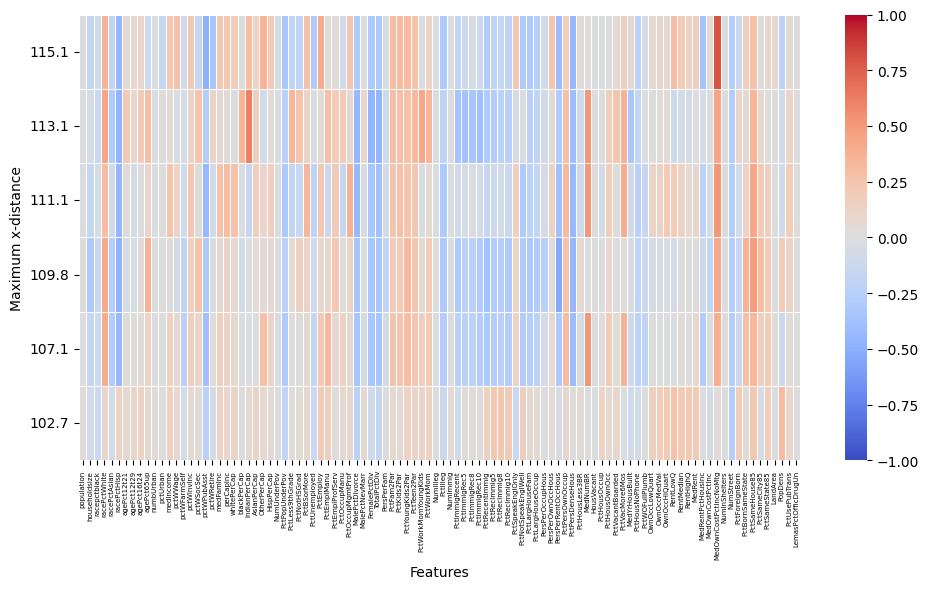

In [15]:
prueba.plot_heatmap(col_names,epsList=[115.1,113.1,111.1,109.8,107.1,102.7],p=1,theta=100)


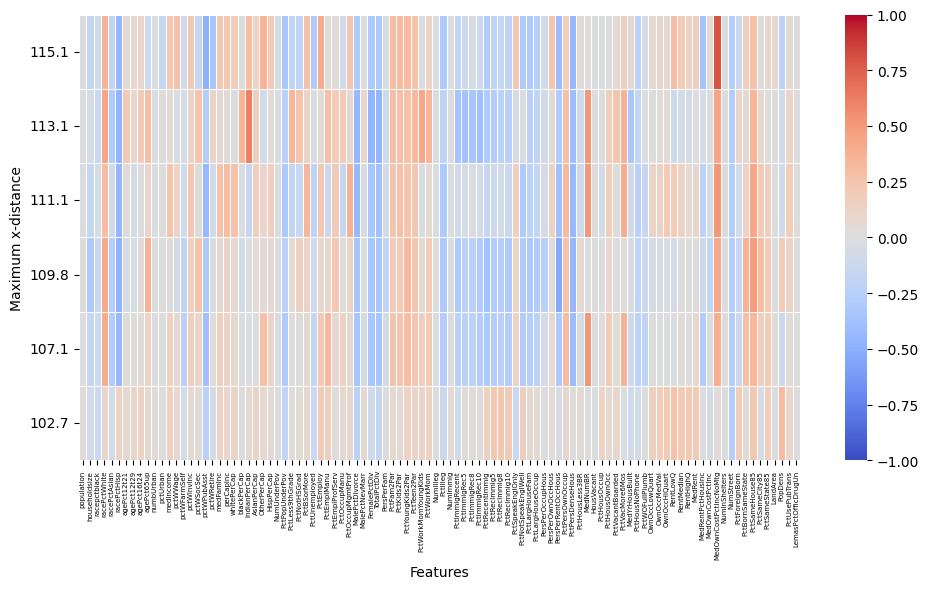

In [ ]:
prueba.plot_heatmap(col_names,epsList=[115.1,113.1,111.1,109.8,107.1,102.7],p=1,theta=0)


100%|██████████| 5/5 [00:00<00:00,  7.82it/s]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO
CASO CON INCERTIDUMBRE CALCULADO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:12<00:00,  2.55s/it]

CASO CON INCERTIDUMBRE CALCULADO


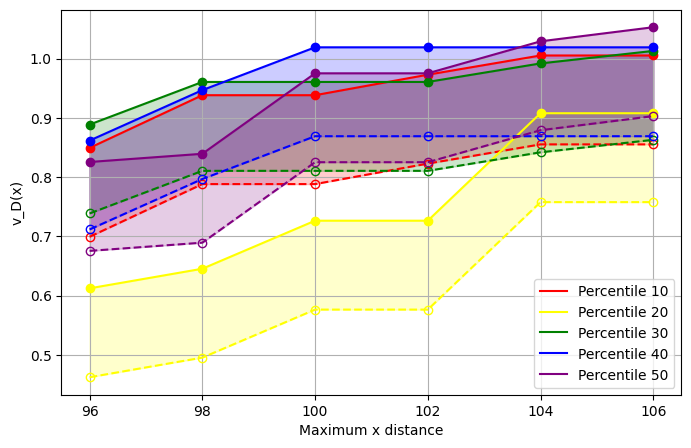

In [16]:
prueba.plotPareto(epsList=[96,98,100,102,104,106],p=1,highTheta=0.15)

100%|██████████| 5/5 [00:00<00:00,  7.61it/s]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO SIN INCERTIDUMBRE CALCULADO
CASO CON INCERTIDUMBRE CALCULADO


 83%|████████▎ | 5/6 [00:01<00:00,  2.80it/s]

CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:13<00:00,  2.60s/it]

CASO CON INCERTIDUMBRE CALCULADO


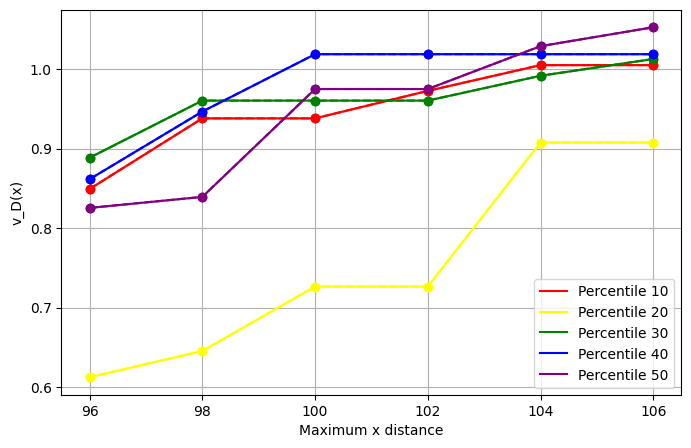

In [18]:
prueba.plotParetoNominal(epsList=[96,98,100,102,104,106],p=1,highTheta=150)

<h2>p=2</h2>

In [28]:
import numpy as np
# a= prueba.percentile(20)
# l=[]
# from tqdm import tqdm
# lis = list(np.arange(100, 120, 0.1))
# anterior = 0
# for i in tqdm(lis):
#     sin = prueba.search(a,p=2,eps=i,theta=0)
#     con = prueba.search(a,p=2,eps=i,theta=0.1)
#     if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
#         l.append(i)
#         anterior=con

In [137]:
print(l)

[np.float64(102.69999999999985), np.float64(107.0999999999996), np.float64(109.79999999999944), np.float64(111.09999999999937), np.float64(113.09999999999926), np.float64(115.09999999999914)]


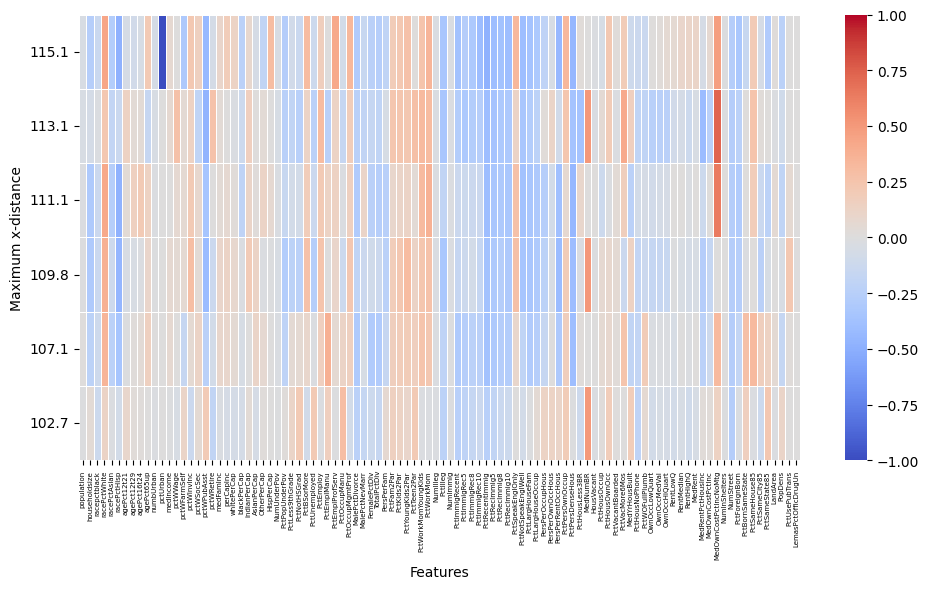

In [38]:
prueba.plot_heatmap(col_names,epsList=[115.1,113.1,111.1,109.8,107.1,102.7],p=2,theta=0.1)


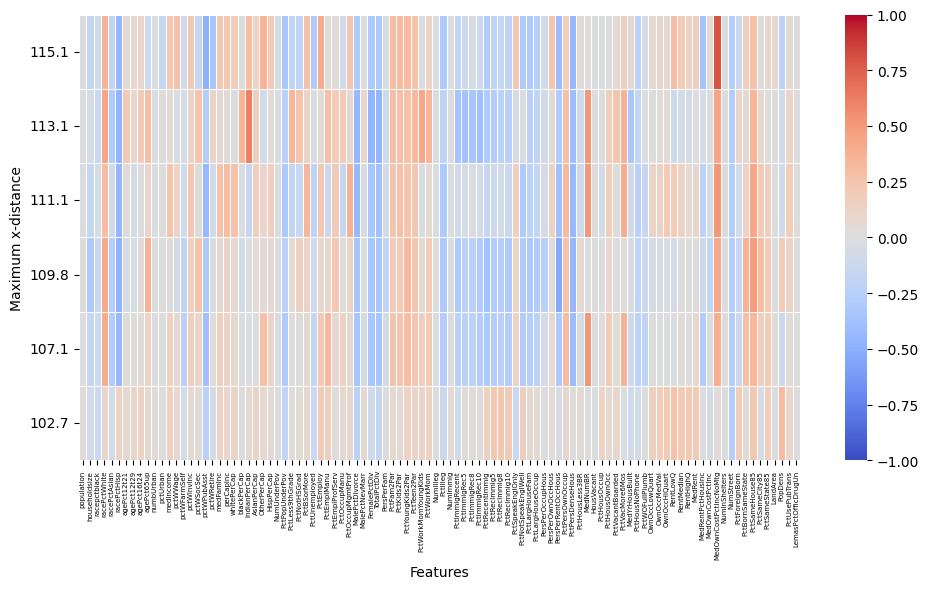

In [39]:
prueba.plot_heatmap(col_names,epsList=[115.1,113.1,111.1,109.8,107.1,102.7],p=2,theta=0)


100%|██████████| 5/5 [00:00<00:00,  7.84it/s]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO
CASO CON INCERTIDUMBRE CALCULADO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:12<00:00,  2.60s/it]

CASO CON INCERTIDUMBRE CALCULADO


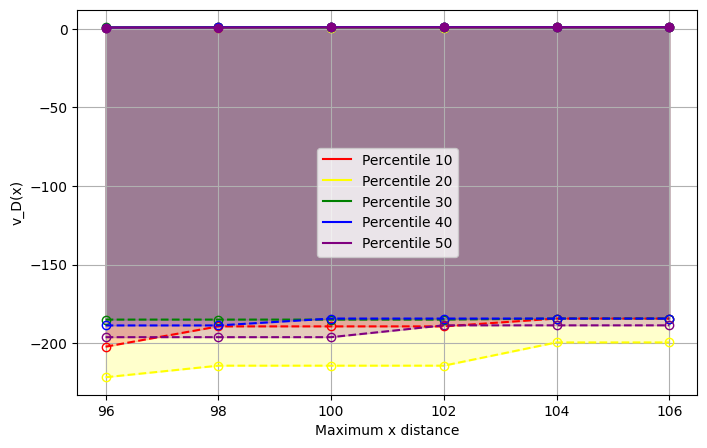

In [19]:
prueba.plotPareto(epsList=[96,98,100,102,104,106],p=2,highTheta=50)

100%|██████████| 5/5 [00:00<00:00,  7.60it/s]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:13<00:00,  2.62s/it]

CASO CON INCERTIDUMBRE CALCULADO


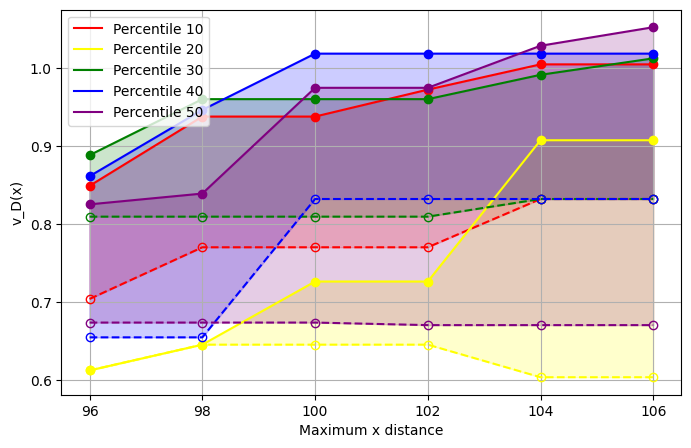

In [20]:
prueba.plotParetoNominal(epsList=[96,98,100,102,104,106],p=2,highTheta=50)

<h2>p=3</h2>

In [17]:
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
import numpy as np
lis = list(np.arange(100, 120, 0.1))
anterior = 0
for i in tqdm(lis):
    sin = prueba.search(a,p=3,eps=i,theta=0)
    con = prueba.search(a,p=3,eps=i,theta=0.1)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con

100%|██████████| 200/200 [02:06<00:00,  1.58it/s]


In [19]:
print(l)

[np.float64(102.69999999999985), np.float64(104.89999999999972), np.float64(109.79999999999944), np.float64(111.09999999999937), np.float64(111.99999999999932), np.float64(112.3999999999993), np.float64(115.09999999999914), np.float64(118.79999999999893)]


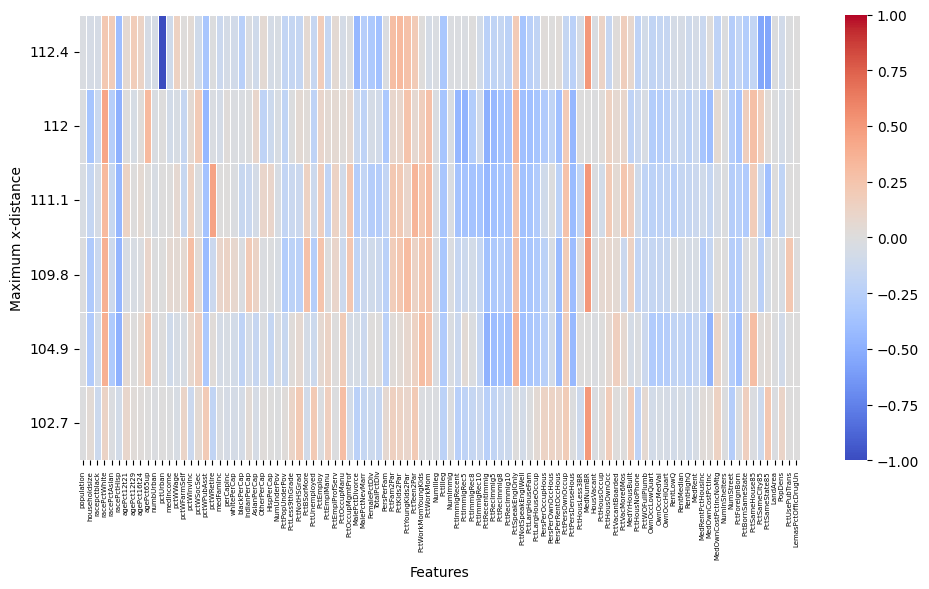

In [56]:
prueba.plot_heatmap(col_names,epsList=[112.4,112,111.1,109.8,104.9,102.7],p=3,theta=0.1)


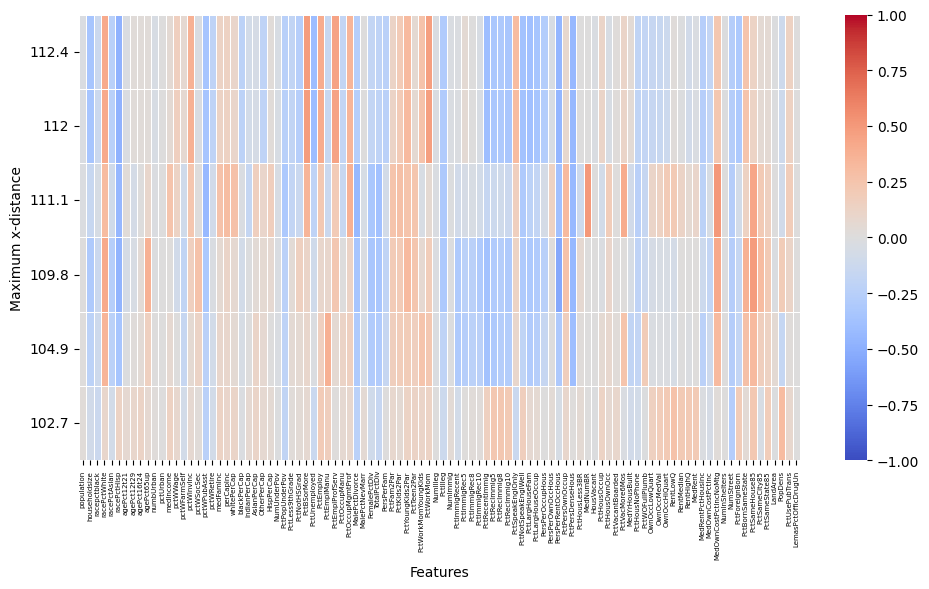

In [57]:
prueba.plot_heatmap(col_names,epsList=[112.4,112,111.1,109.8,104.9,102.7],p=3,theta=0)


100%|██████████| 5/5 [00:00<00:00,  7.41it/s]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO
CASO CON INCERTIDUMBRE CALCULADO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [00:13<00:00,  2.60s/it]

CASO CON INCERTIDUMBRE CALCULADO


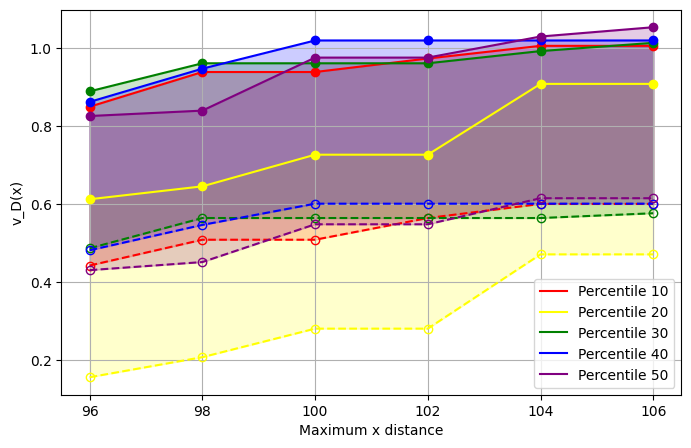

In [62]:
prueba.plotPareto(epsList=[96,98,100,102,104,106],p=3,highTheta=0.05)

<h1>ONE HIDDEN LAYER</h1>

In [65]:
from NNPredictionDRO import NNPredictionDRO
prueba = NNPredictionDRO(X,y)


In [66]:
prueba.fit()

<h2>p=2</h2>

In [27]:
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
import numpy as np
lis = list(np.arange(100, 120, 0.1))
anterior = 0
for i in tqdm(lis):
    sin = prueba.search(a,p=2,eps=i,theta=0)
    con = prueba.search(a,p=2,eps=i,theta=0.1)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con

100%|██████████| 200/200 [43:31<00:00, 13.06s/it]


In [28]:
list(l)

[np.float64(100.0),
 np.float64(101.19999999999993),
 np.float64(105.49999999999969),
 np.float64(108.39999999999952),
 np.float64(108.99999999999949),
 np.float64(111.09999999999937),
 np.float64(115.49999999999912)]

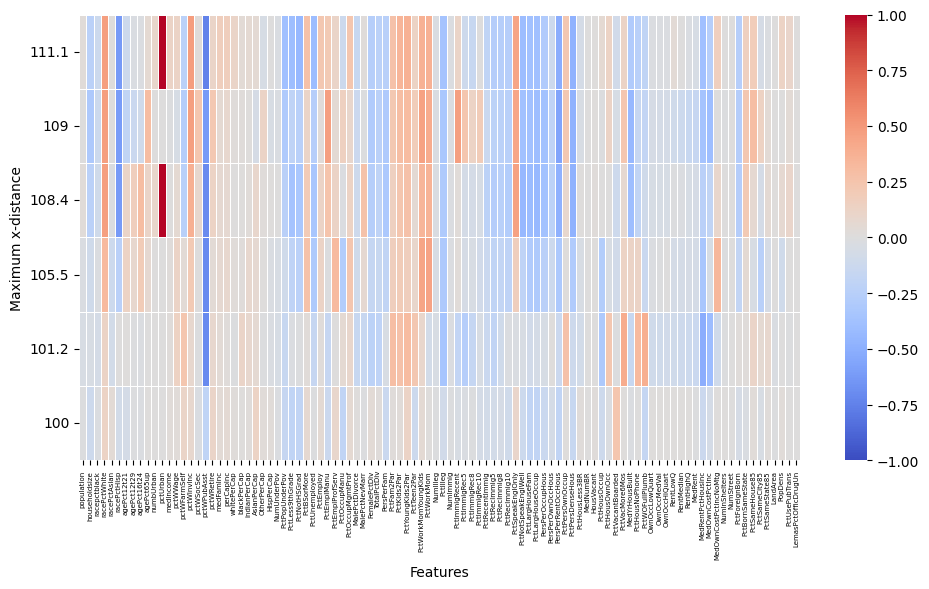

In [67]:
prueba.plot_heatmap(col_names,epsList=[111.1,109,108.4,105.5,101.2,100],p=2,theta=0.1)


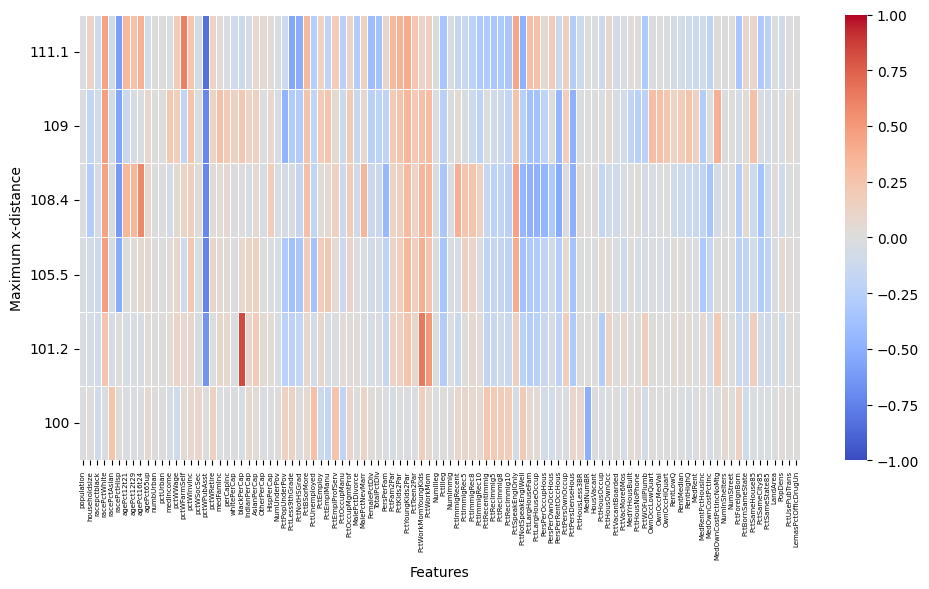

In [68]:
prueba.plot_heatmap(col_names,epsList=[111.1,109,108.4,105.5,101.2,100],p=2,theta=0)


100%|██████████| 5/5 [00:17<00:00,  3.58s/it]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [21:55<00:00, 263.11s/it]

CASO CON INCERTIDUMBRE CALCULADO


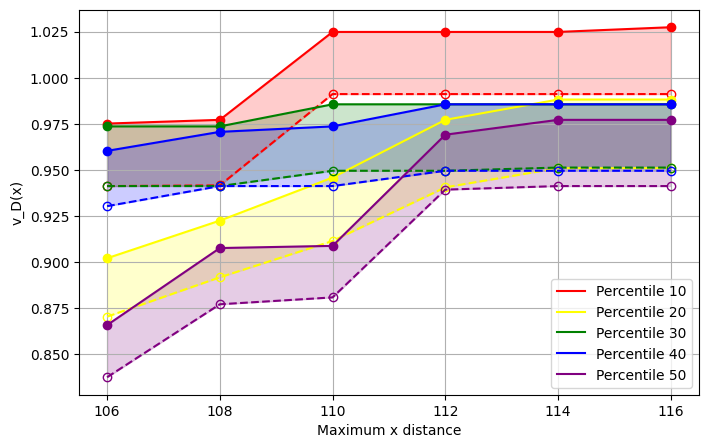

In [69]:
prueba.plotPareto(p=2,epsList=[106,108,110,112,114,116],highTheta=0.0001)

<h2>p=3</h2>

In [ ]:
a= prueba.percentile(20)
l=[]
from tqdm import tqdm
import numpy as np
lis = list(np.arange(100, 120, 1))
anterior = 0
for i in tqdm(lis):
    sin = prueba.search(a,p=3,eps=i,theta=0)
    con = prueba.search(a,p=3,eps=i,theta=0.1)
    if (not np.array_equal(sin,con)) and (not np.array_equal(con,anterior)):
        l.append(i)
        anterior=con

In [37]:
print(lis)

[np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109), np.int64(110), np.int64(111), np.int64(112), np.int64(113), np.int64(114), np.int64(115), np.int64(116), np.int64(117), np.int64(118), np.int64(119)]


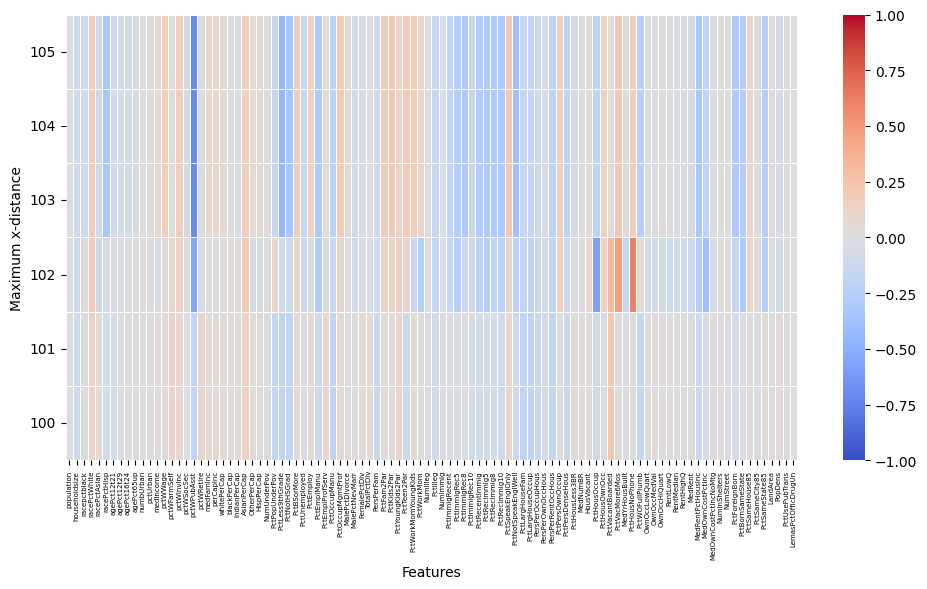

In [70]:
prueba.plot_heatmap(col_names,epsList=[105,104,103,102,101,100],p=3,theta=0.1)


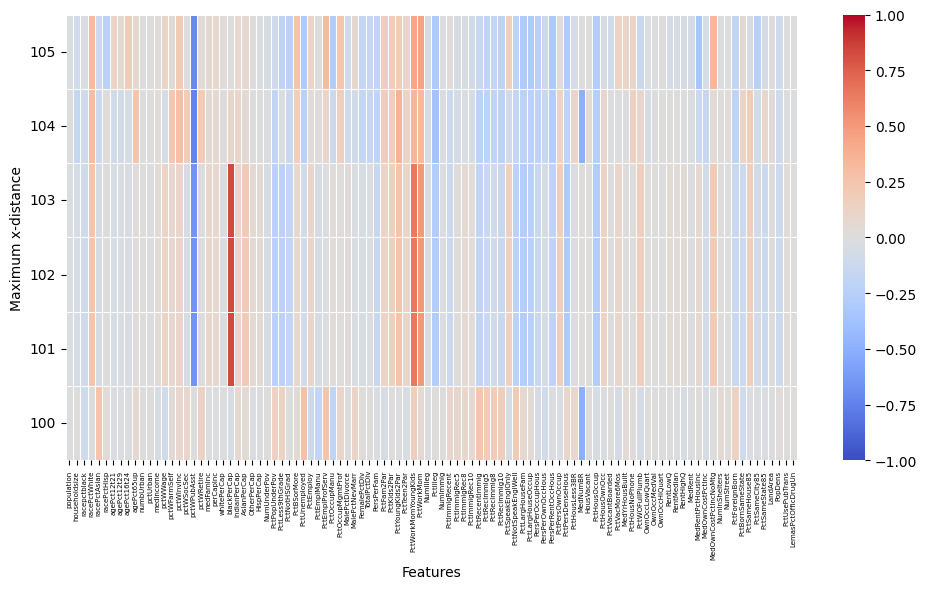

In [71]:
prueba.plot_heatmap(col_names,epsList=[105,104,103,102,101,100],p=3,theta=0)


100%|██████████| 5/5 [00:36<00:00,  7.22s/it]


PERCENTILES CALCULADOS


  0%|          | 0/5 [00:00<?, ?it/s]

CALCULO DEL CONTRAFACTICO DE UN NUEVO INDIVIDUO


CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


...

CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


CASO CON INCERTIDUMBRE CALCULADO
CALCULAMOS CON UN NUEVO EPSILON
CASO SIN INCERTIDUMBRE CALCULADO


100%|██████████| 5/5 [1:00:12<00:00, 722.52s/it]

CASO CON INCERTIDUMBRE CALCULADO


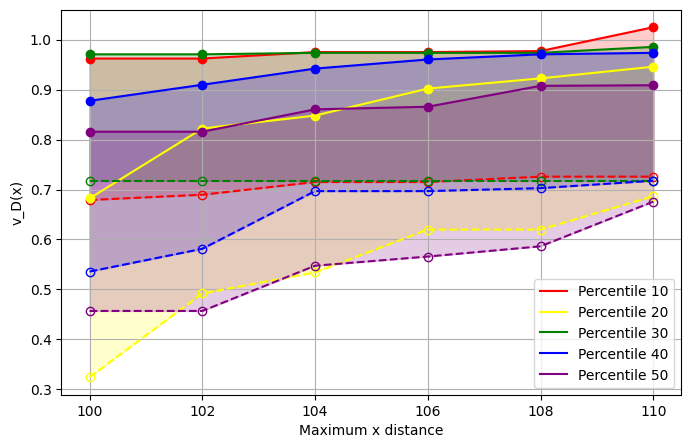

In [5]:
prueba.plotPareto(p=3,epsList=[100,102,104,106,108,110],highTheta=0.0001)